# Project Delay Prediction At 50% Planned Project Life

This notebook builds a prediction model at the planned midpoint of each project. The model uses only information that would have been available by that point:

- Beginning-only project setup features from the approved project feature dataset.
- Change-order information approved on or before the project's planned midpoint date.

The prediction target is the final historical project delay bin:

- Bin 0: before/on time, `PercentDelayed <= 0`
- Bin 1: mildly late, `0 < PercentDelayed <= 25`
- Bin 2: moderately/severely late, `PercentDelayed > 25`

The notebook compares four regularized random forest models:

- Beginning-only project baseline.
- Beginning-only + early approved time change orders.
- Beginning-only + early approved budget change orders.
- Beginning-only + both early approved time and budget change orders.

In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 220)

PROJECT_FEATURE_PATH = Path('custpaydetails_project_feature_table_with_approved_keywords_2026-06-11.csv')
FIELD_DICT_PATH = Path('project_feature_non_keyword_field_dictionary_2026-06-10.csv')
TIME_CO_PATH = Path('change_order_time_lifecycle_with_percentages_2026-06-14.csv')
BUDGET_CO_PATH = Path('change_order_budget_lifecycle_with_percentages_2026-06-14.csv')

RANDOM_STATE = 42
N_ESTIMATORS_FINAL = 220

## Load Project Features And Define Target

The project feature table contains the final retrospective `PercentDelayed` target and the planned project dates needed to compute the 50% cutoff date. Rows without final target labels or valid planned dates are excluded from model training/testing.

In [2]:
project_df = pd.read_csv(PROJECT_FEATURE_PATH, low_memory=False)
field_dict = pd.read_csv(FIELD_DICT_PATH)

for c in ['PLANNEDSTARTDATE', 'PLANNEDENDDATE']:
    project_df[c] = pd.to_datetime(project_df[c], errors='coerce')
project_df['PLANNEDDURATIONDAYS'] = pd.to_numeric(project_df['PLANNEDDURATIONDAYS'], errors='coerce')
project_df['PROJECTMIDPOINTDATE'] = project_df['PLANNEDSTARTDATE'] + pd.to_timedelta(project_df['PLANNEDDURATIONDAYS'] / 2.0, unit='D')

model_df = project_df[
    project_df['PERCENTDELAYED'].notna()
    & project_df['PLANNEDSTARTDATE'].notna()
    & project_df['PLANNEDENDDATE'].notna()
    & (project_df['PLANNEDDURATIONDAYS'] > 0)
].copy()

model_df['DelayBin'] = pd.cut(
    model_df['PERCENTDELAYED'],
    bins=[-np.inf, 0, 25, np.inf],
    labels=[0, 1, 2],
    right=True,
).astype(int)
model_df['DelayBinLabel'] = model_df['DelayBin'].map({0: 'before/on time', 1: 'mildly late', 2: 'moderate/severe late'})

print(f'Project rows: {len(project_df):,}')
print(f'Model rows with target and valid planned midpoint: {len(model_df):,}')
display(model_df['DelayBinLabel'].value_counts().reindex(['before/on time','mildly late','moderate/severe late']).to_frame('Rows'))
display(model_df[['CUSTOMERNAME','PROJECTID','PROJECTNAME','PLANNEDSTARTDATE','PLANNEDENDDATE','PROJECTMIDPOINTDATE','PERCENTDELAYED','DelayBinLabel']].head())

Project rows: 5,762
Model rows with target and valid planned midpoint: 3,469


,Rows
DelayBinLabel,
before/on time,1658
mildly late,120
moderate/severe late,1691


,CUSTOMERNAME,PROJECTID,PROJECTNAME,PLANNEDSTARTDATE,PLANNEDENDDATE,PROJECTMIDPOINTDATE,PERCENTDELAYED,DelayBinLabel
17,Lincoln,2128,EO 86473 Sanitary for Airport Rail Center,2013-10-25 00:00:00,2014-08-12 05:00:00,2014-03-19 12:00:00,-82.474227,before/on time
18,Lincoln,2150,EO 86512 Water in HiMark 19th Addition,2013-12-13 00:00:00,2014-08-15 05:00:00,2014-04-14 12:00:00,-78.367347,before/on time
19,Lincoln,2148,EO 86557 Sanitary Sewer in Fallbrook 29th Addi...,2013-12-13 00:00:00,2014-05-20 05:00:00,2014-03-02 00:00:00,-75.949367,before/on time
21,Lincoln,2159,EO 86620 Water for UNL Soccer & Tennis Facilit...,2014-01-15 06:00:00,2014-10-08 05:00:00,2014-05-28 06:00:00,-23.308271,before/on time
22,Lincoln,2176,EO 86847 Paving for Hartland's Garden Valley 2...,2014-02-11 06:00:00,2015-01-03 06:00:00,2014-07-24 06:00:00,-90.797546,before/on time


## Build Beginning-Only Project Feature Set

The baseline model uses the same beginning-only rules as the prior approved-keyword random forest notebook:

- keep numeric approved keyword features;
- keep non-keyword fields marked as beginning-available or conditionally beginning-available;
- exclude identifiers, customer name, text fields, target fields, and payment/target components.

In [3]:
keyword_prefixes = ('PROJ_KW_', 'CONTRACT_KW_', 'ITEM_KW_')
keyword_cols = [c for c in model_df.columns if c.startswith(keyword_prefixes)]
beginning_available = dict(zip(field_dict['FieldName'], field_dict['BeginningAvailable']))
target_component_cols = set(field_dict.loc[field_dict['FieldGroup'].eq('target/post-payment'), 'FieldName'])
target_component_cols |= {c for c in model_df.columns if c.startswith('TARGET')}
exclude_cols = {
    'RECORD_ID', 'PROJECTID', 'PROJECTNAME', 'PROJECTDESCRIPTION', 'PROJECTCODE',
    'CUSTOMERNAME', 'PROJECTSTATUS', 'PERCENTDELAYED', 'DelayBin', 'DelayBinLabel',
    'PROJECTMIDPOINTDATE'
} | target_component_cols

allowed_beginning_values = {
    'Yes',
    'Yes, if planned duration valid',
    'Yes, if planned end date exists',
    'Yes, if closure dates entered',
    'Yes, if closure date is entered at setup',
}
numeric_cols = [c for c in model_df.columns if pd.api.types.is_numeric_dtype(model_df[c])]
before_nonkeyword_cols = [
    c for c in numeric_cols
    if c in beginning_available
    and beginning_available[c] in allowed_beginning_values
    and c not in exclude_cols
]
baseline_feature_cols = sorted(set(before_nonkeyword_cols) | set(keyword_cols))
baseline_feature_cols = [c for c in baseline_feature_cols if c in numeric_cols and c not in exclude_cols]

feature_summary = pd.DataFrame([{
    'FeatureSet': 'baseline_beginning_only',
    'FeatureCount': len(baseline_feature_cols),
    'KeywordFeatures': sum(c.startswith(keyword_prefixes) for c in baseline_feature_cols),
    'NonKeywordFeatures': sum(not c.startswith(keyword_prefixes) for c in baseline_feature_cols),
}])
display(feature_summary)

,FeatureSet,FeatureCount,KeywordFeatures,NonKeywordFeatures
0,baseline_beginning_only,4188,4141,47


## Aggregate Change Orders Available By The Planned Midpoint

A change order is considered available to the model only if it was approved on or before the project's midpoint date:

```text
ChangeOrderApprovedOn <= ProjectMidpointDate
```

The filtering is recomputed after joining to the project feature table so the 50% date is consistent with the model's `PLANNEDSTARTDATE` and `PLANNEDENDDATE` fields.

In [4]:
def prepare_co_dates(df):
    out = df.copy()
    out['CHANGEORDERAPPROVEDON'] = pd.to_datetime(out['CHANGEORDERAPPROVEDON'], errors='coerce')
    return out

project_midpoints = model_df[['CUSTOMERNAME','PROJECTID','PROJECTMIDPOINTDATE']].copy()

time_co = prepare_co_dates(pd.read_csv(TIME_CO_PATH, low_memory=False))
budget_co = prepare_co_dates(pd.read_csv(BUDGET_CO_PATH, low_memory=False))

time_join = time_co.merge(project_midpoints, on=['CUSTOMERNAME','PROJECTID'], how='inner')
budget_join = budget_co.merge(project_midpoints, on=['CUSTOMERNAME','PROJECTID'], how='inner')

time_early = time_join[time_join['CHANGEORDERAPPROVEDON'].notna() & (time_join['CHANGEORDERAPPROVEDON'] <= time_join['PROJECTMIDPOINTDATE'])].copy()
budget_early = budget_join[budget_join['CHANGEORDERAPPROVEDON'].notna() & (budget_join['CHANGEORDERAPPROVEDON'] <= budget_join['PROJECTMIDPOINTDATE'])].copy()

for c in ['ADDEDDAYS', 'ApprovedPercentOfProject']:
    if c in time_early.columns:
        time_early[c] = pd.to_numeric(time_early[c], errors='coerce')
for c in ['AMOUNTDELTAPRIMARY', 'PositiveDelta', 'NegativeDelta', 'AbsDelta', 'ApprovedPercentOfProject']:
    if c in budget_early.columns:
        budget_early[c] = pd.to_numeric(budget_early[c], errors='coerce')

print(f'Time CO rows joined to modeled projects: {len(time_join):,}')
print(f'Time CO rows approved by midpoint: {len(time_early):,}')
print(f'Budget CO rows joined to modeled projects: {len(budget_join):,}')
print(f'Budget CO rows approved by midpoint: {len(budget_early):,}')

coverage = pd.DataFrame([
    {'Source': 'Time CO', 'ProjectsWithAnyCO': time_join[['CUSTOMERNAME','PROJECTID']].drop_duplicates().shape[0], 'ProjectsWithEarlyApprovedCO': time_early[['CUSTOMERNAME','PROJECTID']].drop_duplicates().shape[0]},
    {'Source': 'Budget CO', 'ProjectsWithAnyCO': budget_join[['CUSTOMERNAME','PROJECTID']].drop_duplicates().shape[0], 'ProjectsWithEarlyApprovedCO': budget_early[['CUSTOMERNAME','PROJECTID']].drop_duplicates().shape[0]},
])
display(coverage)

Time CO rows joined to modeled projects: 1,304
Time CO rows approved by midpoint: 110
Budget CO rows joined to modeled projects: 28,295
Budget CO rows approved by midpoint: 4,042


,Source,ProjectsWithAnyCO,ProjectsWithEarlyApprovedCO
0,Time CO,821,89
1,Budget CO,1787,503


In [5]:
def flatten_columns(df, prefix):
    df = df.copy()
    df.columns = [prefix + '_' + '_'.join([str(x) for x in col if str(x) != '']) if isinstance(col, tuple) else col for col in df.columns]
    return df

# Time change-order features at project grain.
time_features = time_early.groupby(['CUSTOMERNAME','PROJECTID']).agg(
    TIMECO_EARLY_ROW_COUNT=('CHANGEORDERID', 'size'),
    TIMECO_EARLY_DISTINCT_CO_COUNT=('CHANGEORDERID', 'nunique'),
    TIMECO_EARLY_TOTAL_ADDED_DAYS=('ADDEDDAYS', 'sum'),
    TIMECO_EARLY_MEAN_ADDED_DAYS=('ADDEDDAYS', 'mean'),
    TIMECO_EARLY_MEDIAN_ADDED_DAYS=('ADDEDDAYS', 'median'),
    TIMECO_EARLY_MAX_ADDED_DAYS=('ADDEDDAYS', 'max'),
    TIMECO_EARLY_FIRST_APPROVED_PCT=('ApprovedPercentOfProject', 'min'),
    TIMECO_EARLY_LAST_APPROVED_PCT=('ApprovedPercentOfProject', 'max'),
).reset_index()

# Bin counts for early approved time COs.
time_early['EarlyApprovedBin'] = pd.cut(time_early['ApprovedPercentOfProject'], bins=[-np.inf,0,25,50], labels=['PRESTART','PCT_0_25','PCT_25_50'], right=True)
time_bins = pd.crosstab([time_early['CUSTOMERNAME'], time_early['PROJECTID']], time_early['EarlyApprovedBin']).reset_index()
time_bins.columns = ['CUSTOMERNAME','PROJECTID'] + [f'TIMECO_EARLY_COUNT_{c}' for c in time_bins.columns[2:]]
time_features = time_features.merge(time_bins, on=['CUSTOMERNAME','PROJECTID'], how='left')

# Budget change-order features at project grain.
budget_features = budget_early.groupby(['CUSTOMERNAME','PROJECTID']).agg(
    BUDGETCO_EARLY_LINE_COUNT=('CHANGEORDERITEMID', 'size'),
    BUDGETCO_EARLY_DISTINCT_CO_COUNT=('CHANGEORDERID', 'nunique'),
    BUDGETCO_EARLY_NET_DELTA=('AMOUNTDELTAPRIMARY', 'sum'),
    BUDGETCO_EARLY_POSITIVE_DELTA=('PositiveDelta', 'sum'),
    BUDGETCO_EARLY_NEGATIVE_DELTA=('NegativeDelta', 'sum'),
    BUDGETCO_EARLY_ABS_DELTA=('AbsDelta', 'sum'),
    BUDGETCO_EARLY_MEAN_LINE_DELTA=('AMOUNTDELTAPRIMARY', 'mean'),
    BUDGETCO_EARLY_MEDIAN_LINE_DELTA=('AMOUNTDELTAPRIMARY', 'median'),
    BUDGETCO_EARLY_MAX_LINE_DELTA=('AMOUNTDELTAPRIMARY', 'max'),
    BUDGETCO_EARLY_MIN_LINE_DELTA=('AMOUNTDELTAPRIMARY', 'min'),
    BUDGETCO_EARLY_FIRST_APPROVED_PCT=('ApprovedPercentOfProject', 'min'),
    BUDGETCO_EARLY_LAST_APPROVED_PCT=('ApprovedPercentOfProject', 'max'),
).reset_index()

budget_early['EarlyApprovedBin'] = pd.cut(budget_early['ApprovedPercentOfProject'], bins=[-np.inf,0,25,50], labels=['PRESTART','PCT_0_25','PCT_25_50'], right=True)
budget_bins = pd.crosstab([budget_early['CUSTOMERNAME'], budget_early['PROJECTID']], budget_early['EarlyApprovedBin']).reset_index()
budget_bins.columns = ['CUSTOMERNAME','PROJECTID'] + [f'BUDGETCO_EARLY_LINE_COUNT_{c}' for c in budget_bins.columns[2:]]
budget_features = budget_features.merge(budget_bins, on=['CUSTOMERNAME','PROJECTID'], how='left')

# Add normalized budget deltas where project planned value exists.
for df_features in [budget_features]:
    pass

print('Time feature columns:', len(time_features.columns) - 2)
print('Budget feature columns:', len(budget_features.columns) - 2)
display(time_features.head())
display(budget_features.head())

Time feature columns: 11
Budget feature columns: 15


,CUSTOMERNAME,PROJECTID,TIMECO_EARLY_ROW_COUNT,TIMECO_EARLY_DISTINCT_CO_COUNT,TIMECO_EARLY_TOTAL_ADDED_DAYS,TIMECO_EARLY_MEAN_ADDED_DAYS,TIMECO_EARLY_MEDIAN_ADDED_DAYS,TIMECO_EARLY_MAX_ADDED_DAYS,TIMECO_EARLY_FIRST_APPROVED_PCT,TIMECO_EARLY_LAST_APPROVED_PCT,TIMECO_EARLY_COUNT_PRESTART,TIMECO_EARLY_COUNT_PCT_0_25,TIMECO_EARLY_COUNT_PCT_25_50
0,Adams,91,1,1,6.0,6.0,6.0,6.0,46.046437,46.046437,0,0,1
1,Adams,173,2,2,75.0,37.5,37.5,45.0,11.733204,26.823154,0,1,1
2,Adams,181,1,1,20.0,20.0,20.0,20.0,38.466971,38.466971,0,0,1
3,Adams,198,2,2,50.0,25.0,25.0,30.0,25.432238,40.815228,0,0,2
4,Adams,207,5,5,367.0,73.4,60.0,127.0,5.542084,12.752705,0,5,0


,CUSTOMERNAME,PROJECTID,BUDGETCO_EARLY_LINE_COUNT,BUDGETCO_EARLY_DISTINCT_CO_COUNT,BUDGETCO_EARLY_NET_DELTA,BUDGETCO_EARLY_POSITIVE_DELTA,BUDGETCO_EARLY_NEGATIVE_DELTA,BUDGETCO_EARLY_ABS_DELTA,BUDGETCO_EARLY_MEAN_LINE_DELTA,BUDGETCO_EARLY_MEDIAN_LINE_DELTA,BUDGETCO_EARLY_MAX_LINE_DELTA,BUDGETCO_EARLY_MIN_LINE_DELTA,BUDGETCO_EARLY_FIRST_APPROVED_PCT,BUDGETCO_EARLY_LAST_APPROVED_PCT,BUDGETCO_EARLY_LINE_COUNT_PRESTART,BUDGETCO_EARLY_LINE_COUNT_PCT_0_25,BUDGETCO_EARLY_LINE_COUNT_PCT_25_50
0,Adams,4,3,2,859123.4590,859123.459,0.0000,859123.4590,286374.486333,159123.459,700000.00,0.0000,44.260331,47.068586,0,0,3
1,Adams,18,5,2,18.0000,2988.000,-2970.0000,5958.0000,3.600000,800.000,1248.00,-1728.0000,30.175288,30.176820,0,0,5
2,Adams,91,2,1,0.0000,20555.250,-20555.2500,41110.5000,0.000000,0.000,20555.25,-20555.2500,46.046437,46.046437,0,0,2
3,Adams,136,2,1,0.0000,4830.000,-4830.0000,9660.0000,0.000000,0.000,4830.00,-4830.0000,23.830942,23.830942,0,2,0
4,Adams,152,5,1,0.0016,5810.560,-5810.5584,11621.1184,0.000320,1485.960,2476.60,-2905.2798,44.116834,44.116834,0,0,5


## Assemble Modeling Tables

Projects with no early approved change orders receive zero-valued change-order features. That is intentional: the absence of early approved change orders is itself information available at the midpoint.

In [6]:
model_base = model_df.copy()
model_base = model_base.merge(time_features, on=['CUSTOMERNAME','PROJECTID'], how='left')
model_base = model_base.merge(budget_features, on=['CUSTOMERNAME','PROJECTID'], how='left')

co_feature_cols_time = [c for c in time_features.columns if c not in ['CUSTOMERNAME','PROJECTID']]
co_feature_cols_budget = [c for c in budget_features.columns if c not in ['CUSTOMERNAME','PROJECTID']]
for c in co_feature_cols_time + co_feature_cols_budget:
    model_base[c] = pd.to_numeric(model_base[c], errors='coerce').fillna(0)

# Normalize budget CO amounts by project planned value where possible.
if 'PROJECTPLANNEDVALUE' in model_base.columns:
    denom = model_base['PROJECTPLANNEDVALUE'].replace(0, np.nan)
    for c in ['BUDGETCO_EARLY_NET_DELTA', 'BUDGETCO_EARLY_POSITIVE_DELTA', 'BUDGETCO_EARLY_NEGATIVE_DELTA', 'BUDGETCO_EARLY_ABS_DELTA']:
        if c in model_base.columns:
            new_col = c + '_SHARE_OF_PROJECT_PLANNED_VALUE'
            model_base[new_col] = (model_base[c] / denom).replace([np.inf, -np.inf], np.nan).fillna(0)
            co_feature_cols_budget.append(new_col)

feature_sets = {
    'baseline_beginning_only': baseline_feature_cols,
    'baseline_plus_time_co_by_50pct': baseline_feature_cols + co_feature_cols_time,
    'baseline_plus_budget_co_by_50pct': baseline_feature_cols + co_feature_cols_budget,
    'baseline_plus_time_and_budget_co_by_50pct': baseline_feature_cols + co_feature_cols_time + co_feature_cols_budget,
}

feature_set_summary = pd.DataFrame([
    {
        'FeatureSet': name,
        'FeatureCount': len(cols),
        'ProjectBeginningFeatures': len(baseline_feature_cols),
        'TimeCOFeatures': sum(c in co_feature_cols_time for c in cols),
        'BudgetCOFeatures': sum(c in co_feature_cols_budget for c in cols),
    }
    for name, cols in feature_sets.items()
])
display(feature_set_summary)

early_co_project_flags = pd.DataFrame({
    'HasEarlyTimeCO': model_base['TIMECO_EARLY_DISTINCT_CO_COUNT'].fillna(0) > 0 if 'TIMECO_EARLY_DISTINCT_CO_COUNT' in model_base else False,
    'HasEarlyBudgetCO': model_base['BUDGETCO_EARLY_DISTINCT_CO_COUNT'].fillna(0) > 0 if 'BUDGETCO_EARLY_DISTINCT_CO_COUNT' in model_base else False,
    'DelayBinLabel': model_base['DelayBinLabel'],
})
display(pd.crosstab(early_co_project_flags['DelayBinLabel'], early_co_project_flags['HasEarlyTimeCO'], margins=True))
display(pd.crosstab(early_co_project_flags['DelayBinLabel'], early_co_project_flags['HasEarlyBudgetCO'], margins=True))

,FeatureSet,FeatureCount,ProjectBeginningFeatures,TimeCOFeatures,BudgetCOFeatures
0,baseline_beginning_only,4188,4188,0,0
1,baseline_plus_time_co_by_50pct,4199,4188,11,0
2,baseline_plus_budget_co_by_50pct,4207,4188,0,19
3,baseline_plus_time_and_budget_co_by_50pct,4218,4188,11,19


HasEarlyTimeCO,False,True,All
DelayBinLabel,,,
before/on time,1640,18,1658
mildly late,110,10,120
moderate/severe late,1630,61,1691
All,3380,89,3469


HasEarlyBudgetCO,False,True,All
DelayBinLabel,,,
before/on time,1478,180,1658
mildly late,89,31,120
moderate/severe late,1399,292,1691
All,2966,503,3469


## Train/Test Splits

The notebook uses two validation views:

- Hash 80/20 split for stable general holdout performance.
- Time split where training projects are older than testing projects, based on planned start date.

The regularization tuning is performed on the hash-training fold only and then reused across both validation views.

In [7]:
def stable_hash_fraction(*parts):
    key = '||'.join('' if pd.isna(p) else str(p) for p in parts)
    digest = hashlib.md5(key.encode('utf-8')).hexdigest()
    return int(digest[:12], 16) / float(16**12)

split_df = model_base[['CUSTOMERNAME','PROJECTID','PLANNEDSTARTDATE','DelayBin']].copy()
split_df['HashFrac'] = [stable_hash_fraction(c, p) for c, p in zip(split_df['CUSTOMERNAME'], split_df['PROJECTID'])]
hash_train_idx = split_df.index[split_df['HashFrac'] < 0.80]
hash_test_idx = split_df.index[split_df['HashFrac'] >= 0.80]

time_cutoff = split_df['PLANNEDSTARTDATE'].quantile(0.80)
time_train_idx = split_df.index[split_df['PLANNEDSTARTDATE'] <= time_cutoff]
time_test_idx = split_df.index[split_df['PLANNEDSTARTDATE'] > time_cutoff]

split_summary = pd.DataFrame([
    {'Split': 'hash_80_20', 'TrainRows': len(hash_train_idx), 'TestRows': len(hash_test_idx), 'Cutoff': ''},
    {'Split': 'time_old_80_new_20', 'TrainRows': len(time_train_idx), 'TestRows': len(time_test_idx), 'Cutoff': str(time_cutoff.date())},
])
display(split_summary)
print('Hash train label distribution')
display(model_base.loc[hash_train_idx, 'DelayBinLabel'].value_counts().to_frame('Rows'))
print('Hash test label distribution')
display(model_base.loc[hash_test_idx, 'DelayBinLabel'].value_counts().to_frame('Rows'))

,Split,TrainRows,TestRows,Cutoff
0,hash_80_20,2743,726,
1,time_old_80_new_20,2776,693,2024-03-21


Hash train label distribution


,Rows
DelayBinLabel,
moderate/severe late,1343
before/on time,1299
mildly late,101


Hash test label distribution


,Rows
DelayBinLabel,
before/on time,359
moderate/severe late,348
mildly late,19


## Regularized Random Forest Utilities

The model is a random forest classifier with regularization controls tuned by cross-validation on the hash-training fold. The tuning objective is balanced accuracy for the three-bin target.

In [8]:
def make_classifier(params=None, n_estimators=N_ESTIMATORS_FINAL):
    defaults = dict(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        n_jobs=-1,
        max_features='sqrt',
        min_samples_leaf=10,
        min_samples_split=10,
    )
    defaults.update(params or {})
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(**defaults)),
    ])


def tune_feature_set(feature_set_name, feature_cols, train_idx):
    X_train = model_base.loc[list(train_idx), feature_cols]
    y_train = model_base.loc[list(train_idx), 'DelayBin']
    estimator = make_classifier(n_estimators=120)
    param_grid = {
        'model__max_depth': [8, 16, None],
        'model__min_samples_leaf': [10, 20],
        'model__max_features': ['sqrt', 0.15],
        'model__min_samples_split': [10],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    search = GridSearchCV(estimator, param_grid=param_grid, scoring='balanced_accuracy', cv=cv, n_jobs=-1, refit=False)
    search.fit(X_train, y_train)
    params = {k.replace('model__',''): v for k, v in search.best_params_.items()}
    return {'FeatureSet': feature_set_name, 'BestCVBalancedAccuracy': search.best_score_, **params}


def params_from_row(row):
    params = {}
    for c in ['max_depth','min_samples_leaf','min_samples_split','max_features']:
        if c in row and pd.notna(row[c]):
            v = row[c]
            if c in ['max_depth','min_samples_leaf','min_samples_split']:
                params[c] = int(v)
            elif isinstance(v, (float, int, np.floating, np.integer)):
                params[c] = float(v)
            else:
                params[c] = v
    return params


def evaluate_model(feature_set_name, feature_cols, train_idx, test_idx, split_name, params):
    X_train = model_base.loc[list(train_idx), feature_cols]
    y_train = model_base.loc[list(train_idx), 'DelayBin']
    X_test = model_base.loc[list(test_idx), feature_cols]
    y_test = model_base.loc[list(test_idx), 'DelayBin']
    model = make_classifier(params=params)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)
    metrics = {
        'FeatureSet': feature_set_name,
        'Split': split_name,
        'TrainRows': len(train_idx),
        'TestRows': len(test_idx),
        'Accuracy': accuracy_score(y_test, pred),
        'BalancedAccuracy': balanced_accuracy_score(y_test, pred),
        'MacroF1': f1_score(y_test, pred, average='macro', zero_division=0),
        'WeightedF1': f1_score(y_test, pred, average='weighted', zero_division=0),
    }
    try:
        metrics['OVR_AUC'] = roc_auc_score(y_test, prob, multi_class='ovr', average='macro')
    except Exception:
        metrics['OVR_AUC'] = np.nan
    return metrics, model, y_test, pred, prob


def feature_importance(model, feature_cols, top_n=40):
    imp = model.named_steps['model'].feature_importances_
    return pd.DataFrame({'Feature': feature_cols, 'Importance': imp}).sort_values('Importance', ascending=False).head(top_n)

## Tune Regularization And Evaluate Models

Tuning is done once per feature set on the hash-training split. Those parameters are then used for both the hash holdout and time holdout evaluations.

In [9]:
tuning_rows = []
for name, cols in feature_sets.items():
    print(f'Tuning {name}...')
    tuning_rows.append(tune_feature_set(name, cols, hash_train_idx))
tuned_params = pd.DataFrame(tuning_rows)
display(tuned_params)
tuned_params.to_csv('project_delay_50pct_co_regularization_params_2026-06-14.csv', index=False)

results = []
fitted = {}
for _, row in tuned_params.iterrows():
    name = row['FeatureSet']
    cols = feature_sets[name]
    params = params_from_row(row)
    for split_name, train_idx, test_idx in [
        ('hash_80_20', hash_train_idx, hash_test_idx),
        ('time_old_80_new_20', time_train_idx, time_test_idx),
    ]:
        metrics, model, y_test, pred, prob = evaluate_model(name, cols, train_idx, test_idx, split_name, params)
        metrics.update(params)
        results.append(metrics)
        fitted[(name, split_name)] = {'model': model, 'y_test': y_test, 'pred': pred, 'prob': prob, 'features': cols}

results_df = pd.DataFrame(results)
display(results_df.sort_values(['Split','FeatureSet']))
results_df.to_csv('project_delay_50pct_co_model_results_2026-06-14.csv', index=False)

Tuning baseline_beginning_only...


Tuning baseline_plus_time_co_by_50pct...


Tuning baseline_plus_budget_co_by_50pct...


Tuning baseline_plus_time_and_budget_co_by_50pct...


,FeatureSet,BestCVBalancedAccuracy,max_depth,max_features,min_samples_leaf,min_samples_split
0,baseline_beginning_only,0.671246,16.0,0.15,20,10
1,baseline_plus_time_co_by_50pct,0.685956,NaN,sqrt,20,10
2,baseline_plus_budget_co_by_50pct,0.678186,8.0,sqrt,20,10
3,baseline_plus_time_and_budget_co_by_50pct,0.690990,16.0,sqrt,20,10


,FeatureSet,Split,TrainRows,TestRows,Accuracy,BalancedAccuracy,MacroF1,WeightedF1,OVR_AUC,max_depth,min_samples_leaf,min_samples_split,max_features
0,baseline_beginning_only,hash_80_20,2743,726,0.863636,0.724106,0.668618,0.883405,0.919630,16.0,20,10,0.15
4,baseline_plus_budget_co_by_50pct,hash_80_20,2743,726,0.834711,0.737368,0.653204,0.867367,0.907010,8.0,20,10,sqrt
6,baseline_plus_time_and_budget_co_by_50pct,hash_80_20,2743,726,0.847107,0.696202,0.647529,0.871791,0.910324,16.0,20,10,sqrt
2,baseline_plus_time_co_by_50pct,hash_80_20,2743,726,0.841598,0.675814,0.637044,0.866379,0.905925,NaN,20,10,sqrt
1,baseline_beginning_only,time_old_80_new_20,2776,693,0.767677,0.566284,0.567637,0.764413,0.837073,16.0,20,10,0.15
5,baseline_plus_budget_co_by_50pct,time_old_80_new_20,2776,693,0.734488,0.557856,0.558639,0.744648,0.821942,8.0,20,10,sqrt
7,baseline_plus_time_and_budget_co_by_50pct,time_old_80_new_20,2776,693,0.738817,0.532772,0.537530,0.743014,0.816194,16.0,20,10,sqrt
3,baseline_plus_time_co_by_50pct,time_old_80_new_20,2776,693,0.746032,0.544701,0.547883,0.747756,0.817932,NaN,20,10,sqrt


## Model Comparison Charts

The main comparison is whether early approved change orders improve prediction over the beginning-only project baseline.

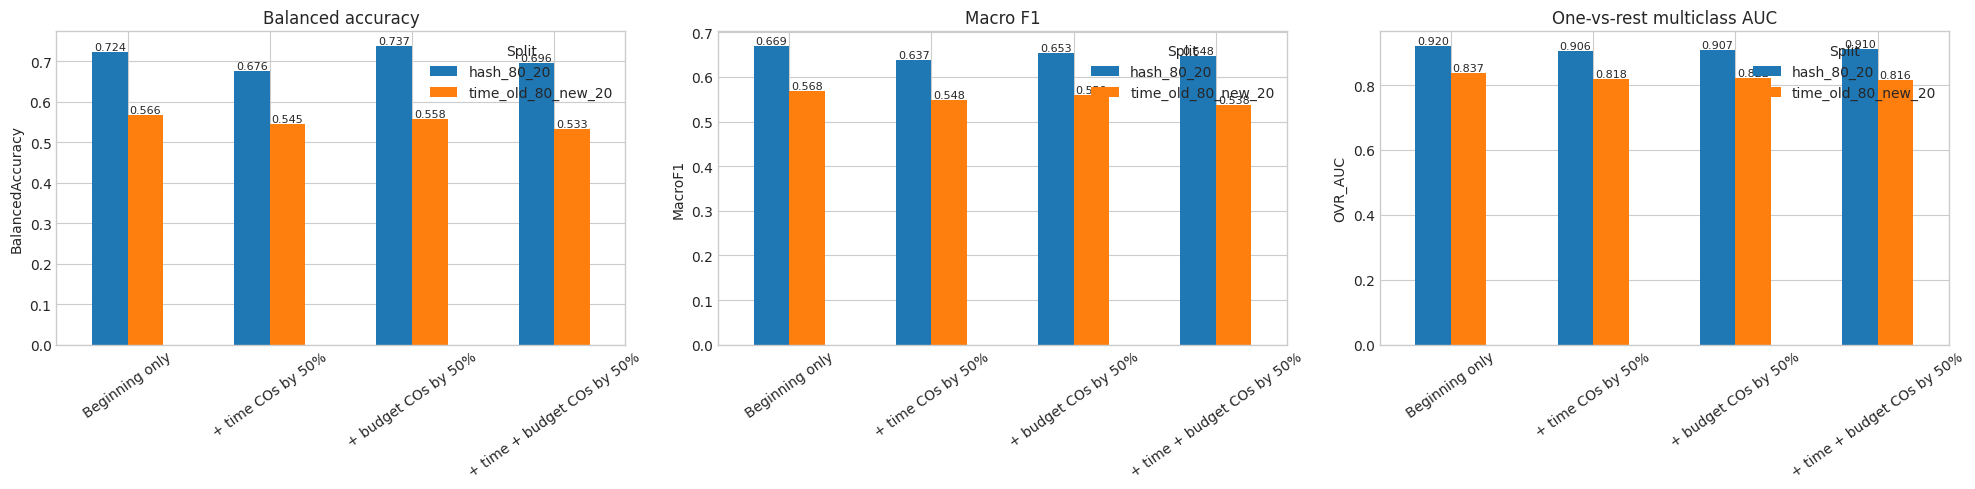

,Split,FeatureSet,BalancedAccuracyLiftVsBaseline,MacroF1LiftVsBaseline,OVR_AUCLiftVsBaseline
0,hash_80_20,Beginning only,+0.000,+0.000,+0.000
1,hash_80_20,+ time COs by 50%,-0.048,-0.032,-0.014
2,hash_80_20,+ budget COs by 50%,+0.013,-0.015,-0.013
3,hash_80_20,+ time + budget COs by 50%,-0.028,-0.021,-0.009
4,time_old_80_new_20,Beginning only,+0.000,+0.000,+0.000
5,time_old_80_new_20,+ time COs by 50%,-0.022,-0.020,-0.019
6,time_old_80_new_20,+ budget COs by 50%,-0.008,-0.009,-0.015
7,time_old_80_new_20,+ time + budget COs by 50%,-0.034,-0.030,-0.021


In [10]:
label_map = {
    'baseline_beginning_only': 'Beginning only',
    'baseline_plus_time_co_by_50pct': '+ time COs by 50%',
    'baseline_plus_budget_co_by_50pct': '+ budget COs by 50%',
    'baseline_plus_time_and_budget_co_by_50pct': '+ time + budget COs by 50%',
}
plot_df = results_df.copy()
plot_df['FeatureSetLabel'] = plot_df['FeatureSet'].map(label_map)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric, title in [
    (axes[0], 'BalancedAccuracy', 'Balanced accuracy'),
    (axes[1], 'MacroF1', 'Macro F1'),
    (axes[2], 'OVR_AUC', 'One-vs-rest multiclass AUC'),
]:
    pivot = plot_df.pivot(index='FeatureSetLabel', columns='Split', values=metric).loc[list(label_map.values())]
    pivot.plot(kind='bar', ax=ax, rot=35)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

# Incremental lift vs baseline by split.
rows = []
for split in results_df['Split'].unique():
    base = results_df[(results_df.Split == split) & (results_df.FeatureSet == 'baseline_beginning_only')].iloc[0]
    for fs in results_df['FeatureSet'].unique():
        row = results_df[(results_df.Split == split) & (results_df.FeatureSet == fs)].iloc[0]
        rows.append({
            'Split': split,
            'FeatureSet': label_map[fs],
            'BalancedAccuracyLiftVsBaseline': row.BalancedAccuracy - base.BalancedAccuracy,
            'MacroF1LiftVsBaseline': row.MacroF1 - base.MacroF1,
            'OVR_AUCLiftVsBaseline': row.OVR_AUC - base.OVR_AUC,
        })
lift_df = pd.DataFrame(rows)
display(lift_df.style.format({'BalancedAccuracyLiftVsBaseline': '{:+.3f}', 'MacroF1LiftVsBaseline': '{:+.3f}', 'OVR_AUCLiftVsBaseline': '{:+.3f}'}))
lift_df.to_csv('project_delay_50pct_co_lift_vs_baseline_2026-06-14.csv', index=False)

## Confusion Matrices

The confusion matrices show where the three-bin classifier is confusing final delay severity categories.

=== hash_80_20 ===


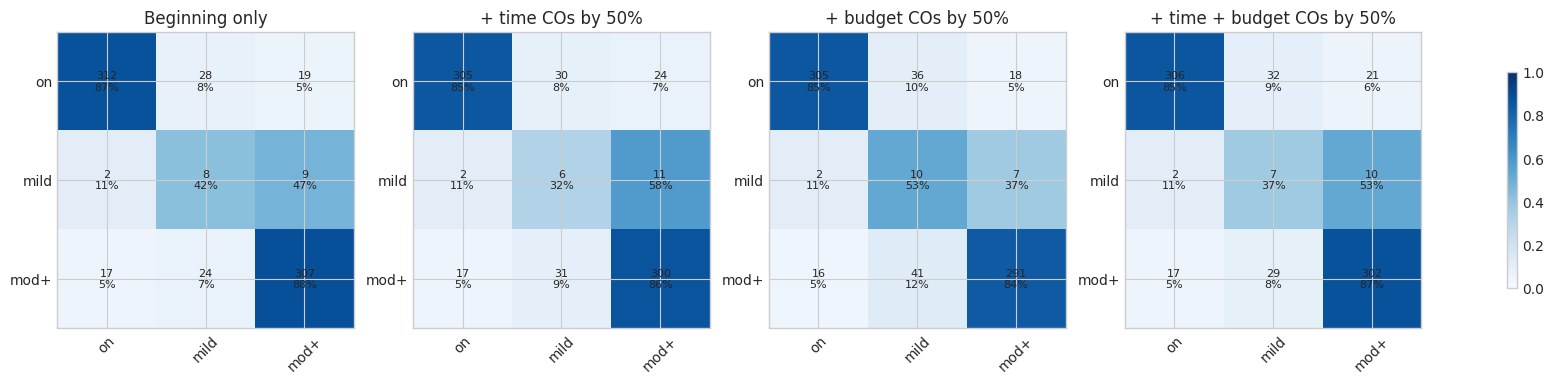

=== time_old_80_new_20 ===


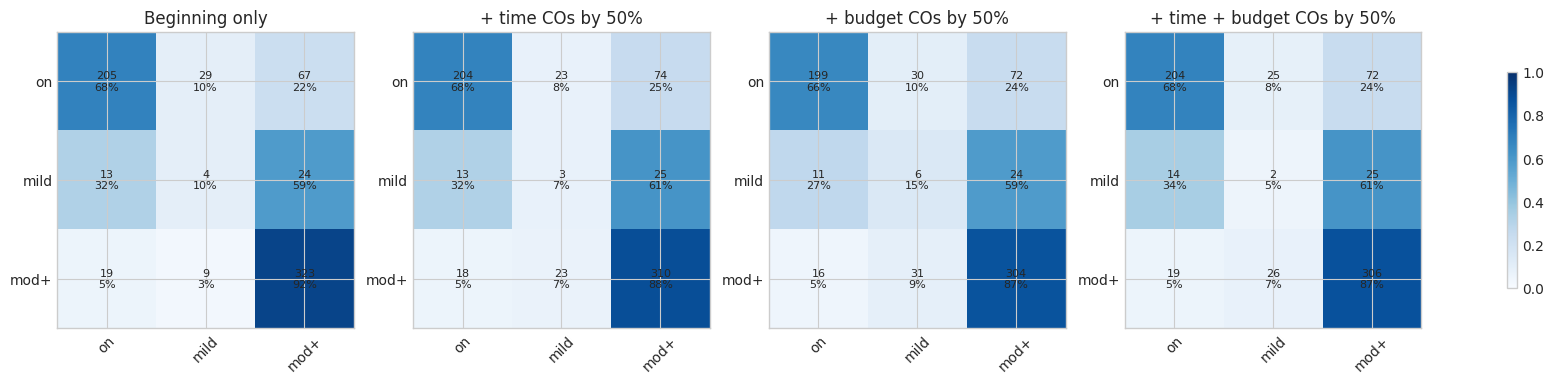

In [11]:
class_names = ['before/on time', 'mildly late', 'moderate/severe late']
for split_name in ['hash_80_20', 'time_old_80_new_20']:
    print(f'=== {split_name} ===')
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    for ax, fs in zip(axes, label_map.keys()):
        item = fitted[(fs, split_name)]
        cm = confusion_matrix(item['y_test'], item['pred'], labels=[0,1,2])
        cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(label_map[fs])
        ax.set_xticks([0,1,2]); ax.set_xticklabels(['on', 'mild', 'mod+'], rotation=45)
        ax.set_yticks([0,1,2]); ax.set_yticklabels(['on', 'mild', 'mod+'])
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f'{cm[i,j]}\n{cm_norm[i,j]:.0%}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
    plt.show()

## Feature Importance

Feature importance is shown for the combined model. Random forest importance is not causal, but it is useful for checking whether the model relies on plausible setup and early change-order signals.

Top importances: hash_80_20


,Feature,Importance,FeatureType
959,DOLLARSPERPLANNEDDAY,0.029222,Beginning project feature
3573,PROJECTPLANNEDVALUE,0.024677,Beginning project feature
3556,MAXITEMPLANNEDVALUE,0.022871,Beginning project feature
957,DOLLARSPERCONTRACT,0.021507,Beginning project feature
3558,MEANITEMPLANNEDVALUE,0.020626,Beginning project feature
0,ABSPROJECTPLANNEDVALUE,0.019432,Beginning project feature
3560,MEDIANITEMPLANNEDVALUE,0.018347,Beginning project feature
4186,UNITPRICEP90,0.018254,Beginning project feature
3555,MAXCONTRACTPLANNEDDURATIONDAYS,0.017882,Beginning project feature
4184,UNITPRICEMAX,0.017686,Beginning project feature


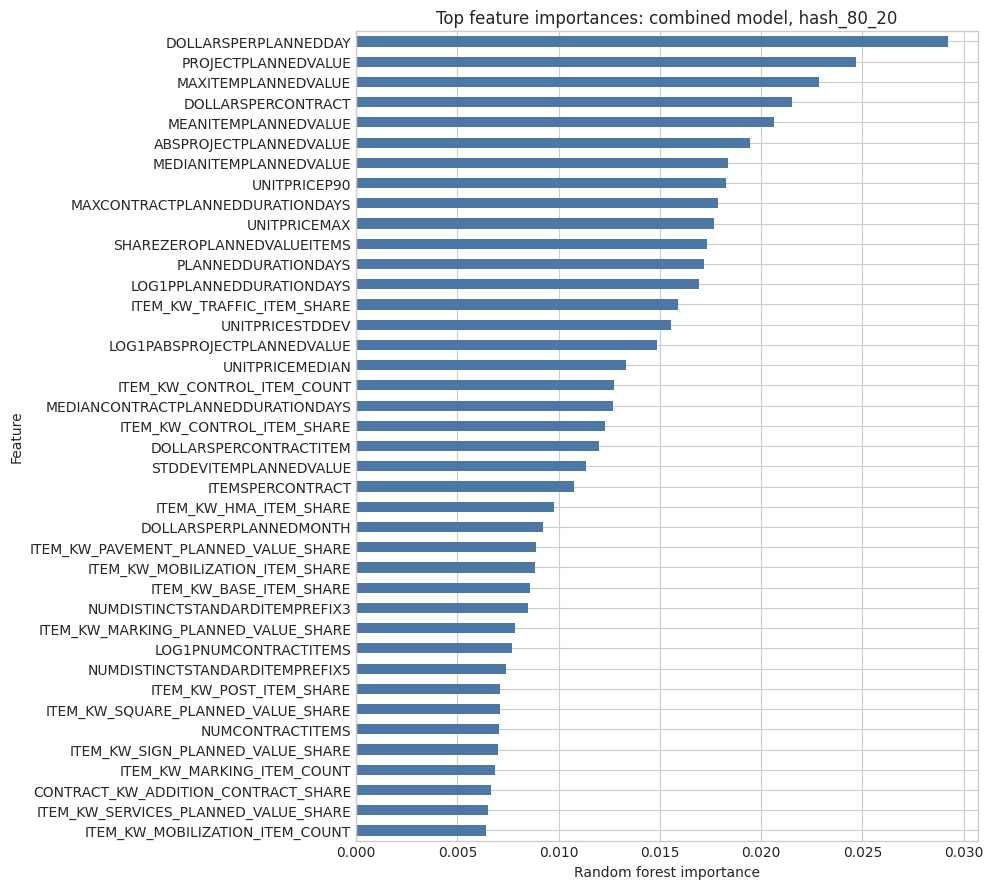

Top importances: time_old_80_new_20


,Feature,Importance,FeatureType
4186,UNITPRICEP90,0.024133,Beginning project feature
3573,PROJECTPLANNEDVALUE,0.023421,Beginning project feature
959,DOLLARSPERPLANNEDDAY,0.022440,Beginning project feature
960,DOLLARSPERPLANNEDMONTH,0.020971,Beginning project feature
3558,MEANITEMPLANNEDVALUE,0.020701,Beginning project feature
3552,LOG1PABSPROJECTPLANNEDVALUE,0.018992,Beginning project feature
4183,STDDEVITEMPLANNEDVALUE,0.018252,Beginning project feature
2362,ITEM_KW_MOBILIZATION_ITEM_SHARE,0.018092,Beginning project feature
3559,MEDIANCONTRACTPLANNEDDURATIONDAYS,0.017257,Beginning project feature
3555,MAXCONTRACTPLANNEDDURATIONDAYS,0.017081,Beginning project feature


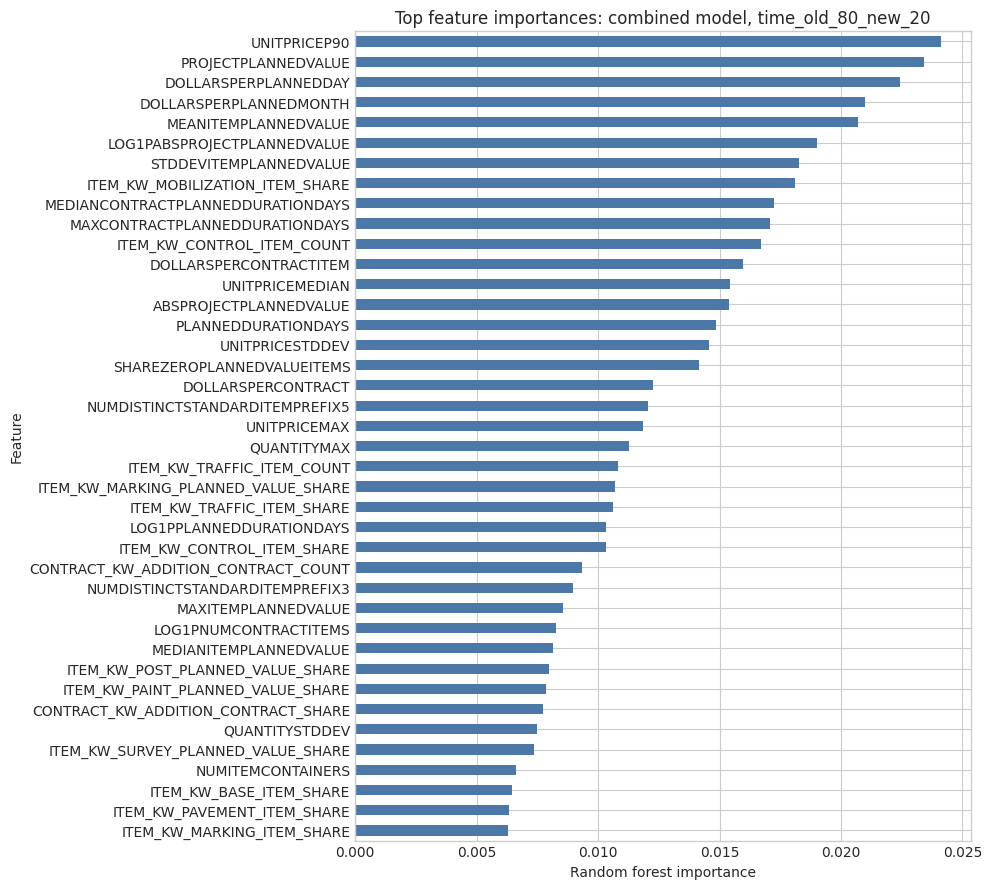

In [12]:
for split_name in ['hash_80_20', 'time_old_80_new_20']:
    key = ('baseline_plus_time_and_budget_co_by_50pct', split_name)
    imp = feature_importance(fitted[key]['model'], fitted[key]['features'], top_n=40)
    imp['FeatureType'] = np.select(
        [imp['Feature'].str.startswith('TIMECO_'), imp['Feature'].str.startswith('BUDGETCO_')],
        ['Early time CO', 'Early budget CO'],
        default='Beginning project feature'
    )
    print(f'Top importances: {split_name}')
    display(imp)
    ax = imp.sort_values('Importance').plot(kind='barh', x='Feature', y='Importance', figsize=(10, 9), legend=False, color='#4c78a8')
    ax.set_title(f'Top feature importances: combined model, {split_name}')
    ax.set_xlabel('Random forest importance')
    plt.tight_layout()
    plt.show()
    imp.to_csv(f'project_delay_50pct_co_combined_importances_{split_name}_2026-06-14.csv', index=False)

## Interpretation Notes

This is a true midpoint prediction setup: change orders approved after the planned midpoint are excluded from the features, while the final delay bin remains the target.

Important caveats:

- Projects without valid planned start/end/duration are excluded because a midpoint cannot be computed.
- Projects with no early approved change orders are retained with zero-valued change-order features.
- The model tests whether early approved change-order information adds predictive value beyond project setup features.
- Approval timing is based on `CHANGEORDERAPPROVEDON`; created-but-not-approved change orders are intentionally excluded from the midpoint change-order feature set.

In [13]:
# Save the assembled project-level modeling table for audit/reuse.
keep_cols = ['CUSTOMERNAME','PROJECTID','PROJECTNAME','PLANNEDSTARTDATE','PLANNEDENDDATE','PROJECTMIDPOINTDATE','PERCENTDELAYED','DelayBin','DelayBinLabel'] + co_feature_cols_time + co_feature_cols_budget
keep_cols = [c for c in keep_cols if c in model_base.columns]
model_base[keep_cols].to_csv('project_delay_50pct_co_project_features_2026-06-14.csv', index=False)
print('Saved audit/model summary CSV outputs.')

Saved audit/model summary CSV outputs.
